=== Dataset Overview ===
Total Rows: 28080
        month   region      service_category      channel  transactions  \
0  2021-07-01  Al-Baha  Business & Licensing       Branch          5727   
1  2021-07-01  Al-Baha  Business & Licensing  Call Center          2575   
2  2021-07-01  Al-Baha  Business & Licensing   Mobile App          1936   
3  2021-07-01  Al-Baha  Business & Licensing   Web Portal          2425   
4  2021-07-01  Al-Baha  Education & Training       Branch          7443   

   unique_users  digital_adoption_pct  avg_completion_min  cost_per_txn_sar  \
0          4745                  33.4               117.0             51.88   
1          1708                  33.4                31.5             24.11   
2           721                  33.4                13.7              6.26   
3          1221                  33.4                19.4              8.63   
4          5923                  37.0                29.4             39.00   

   csat  sla_met_pct  complaint

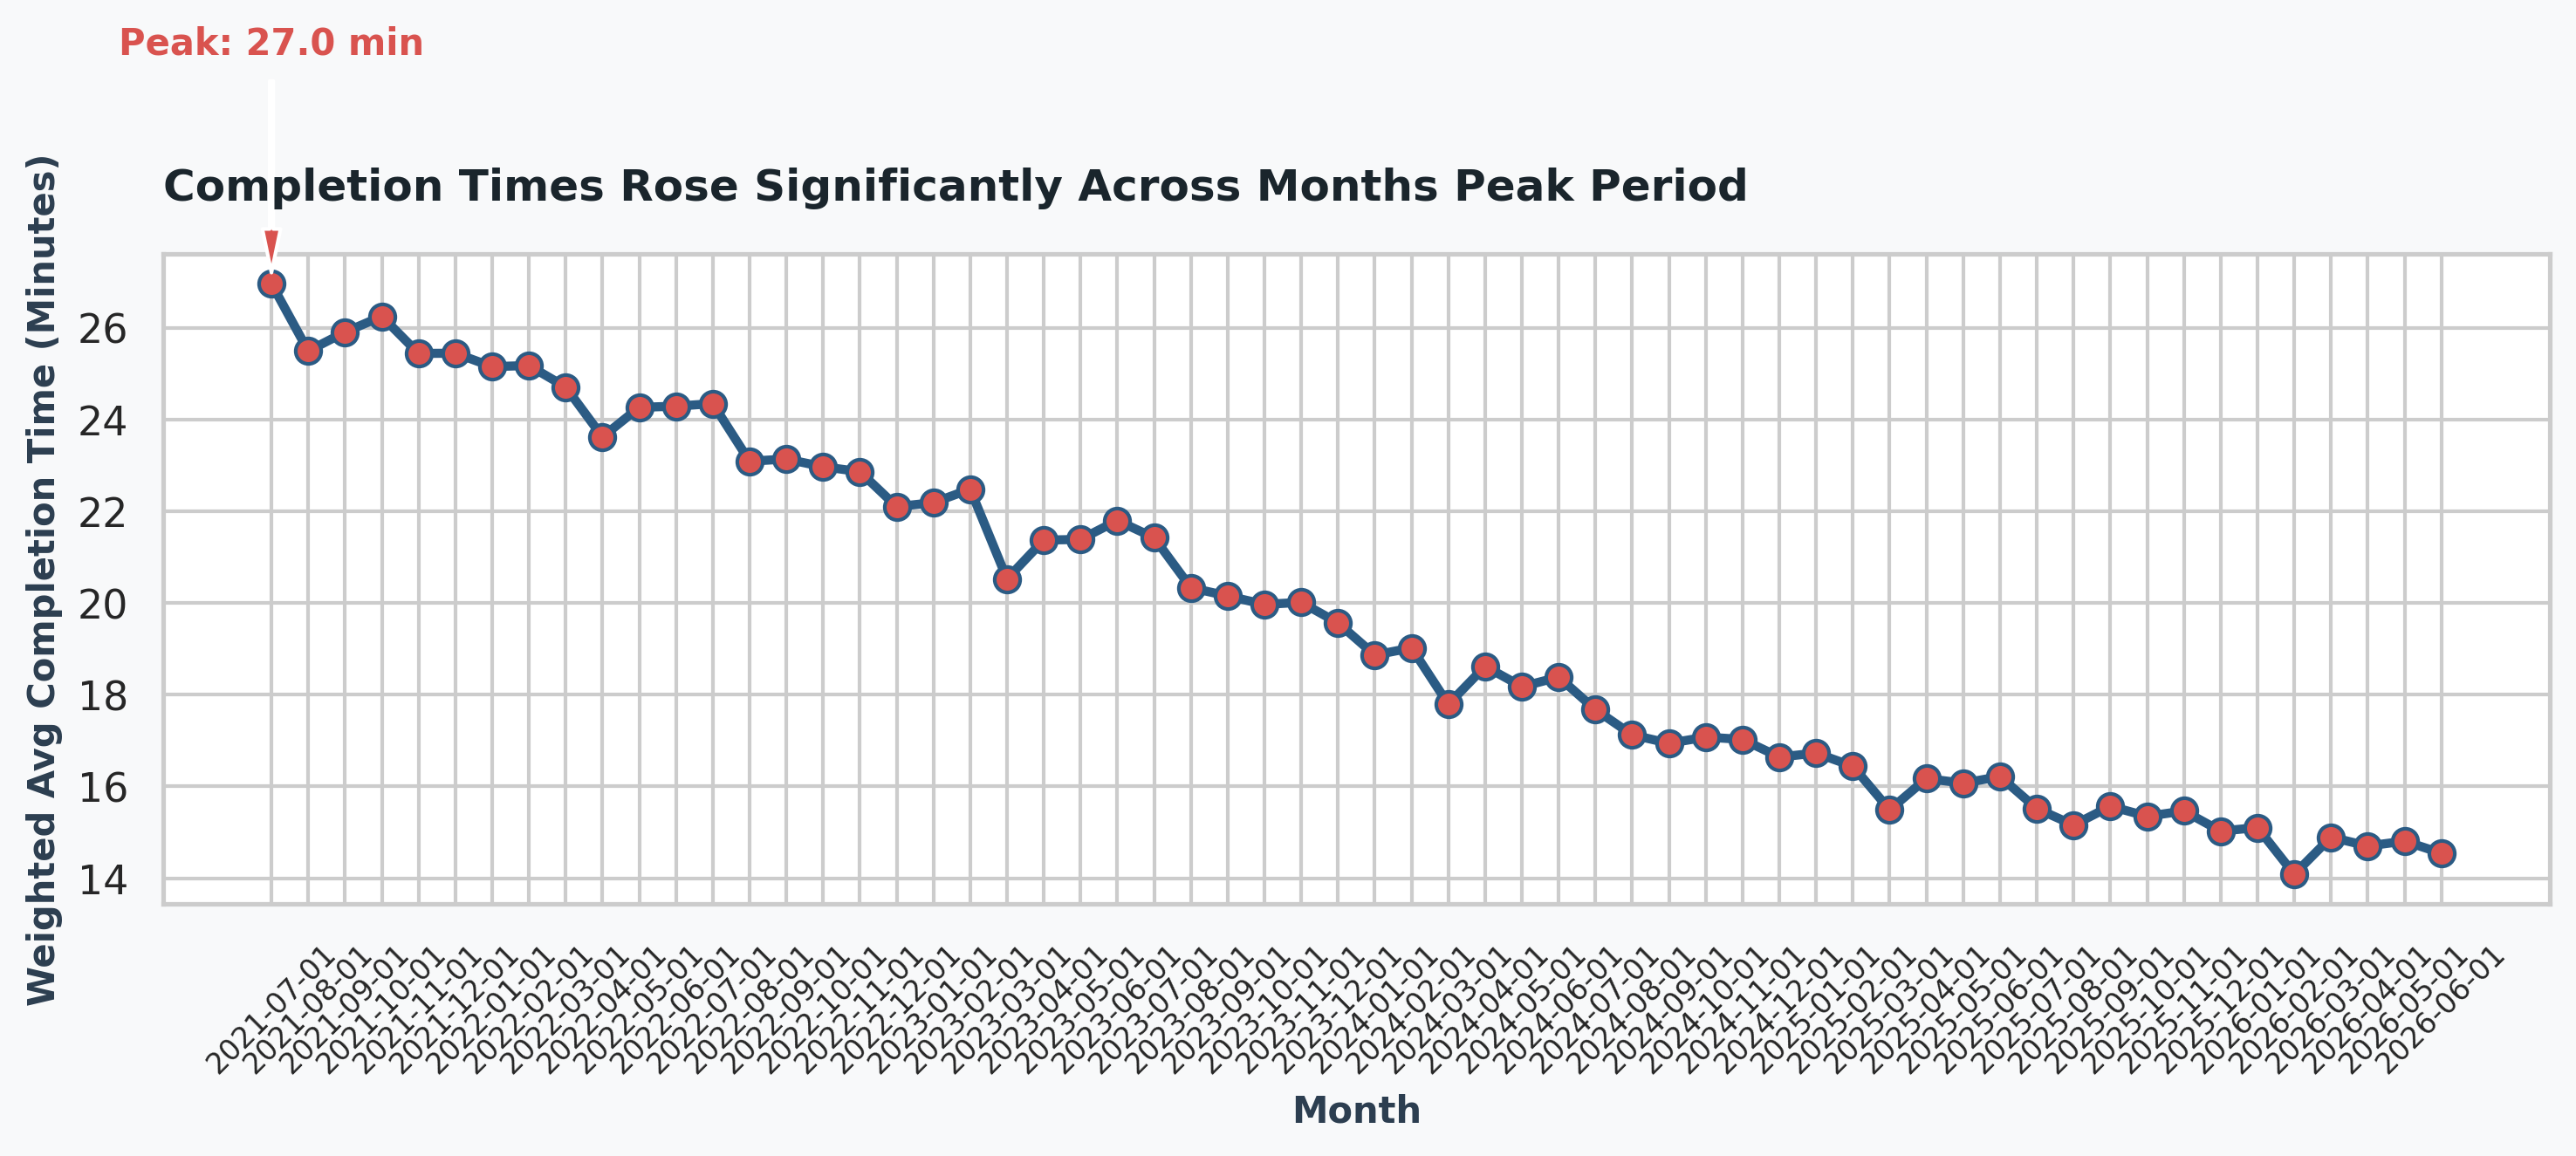

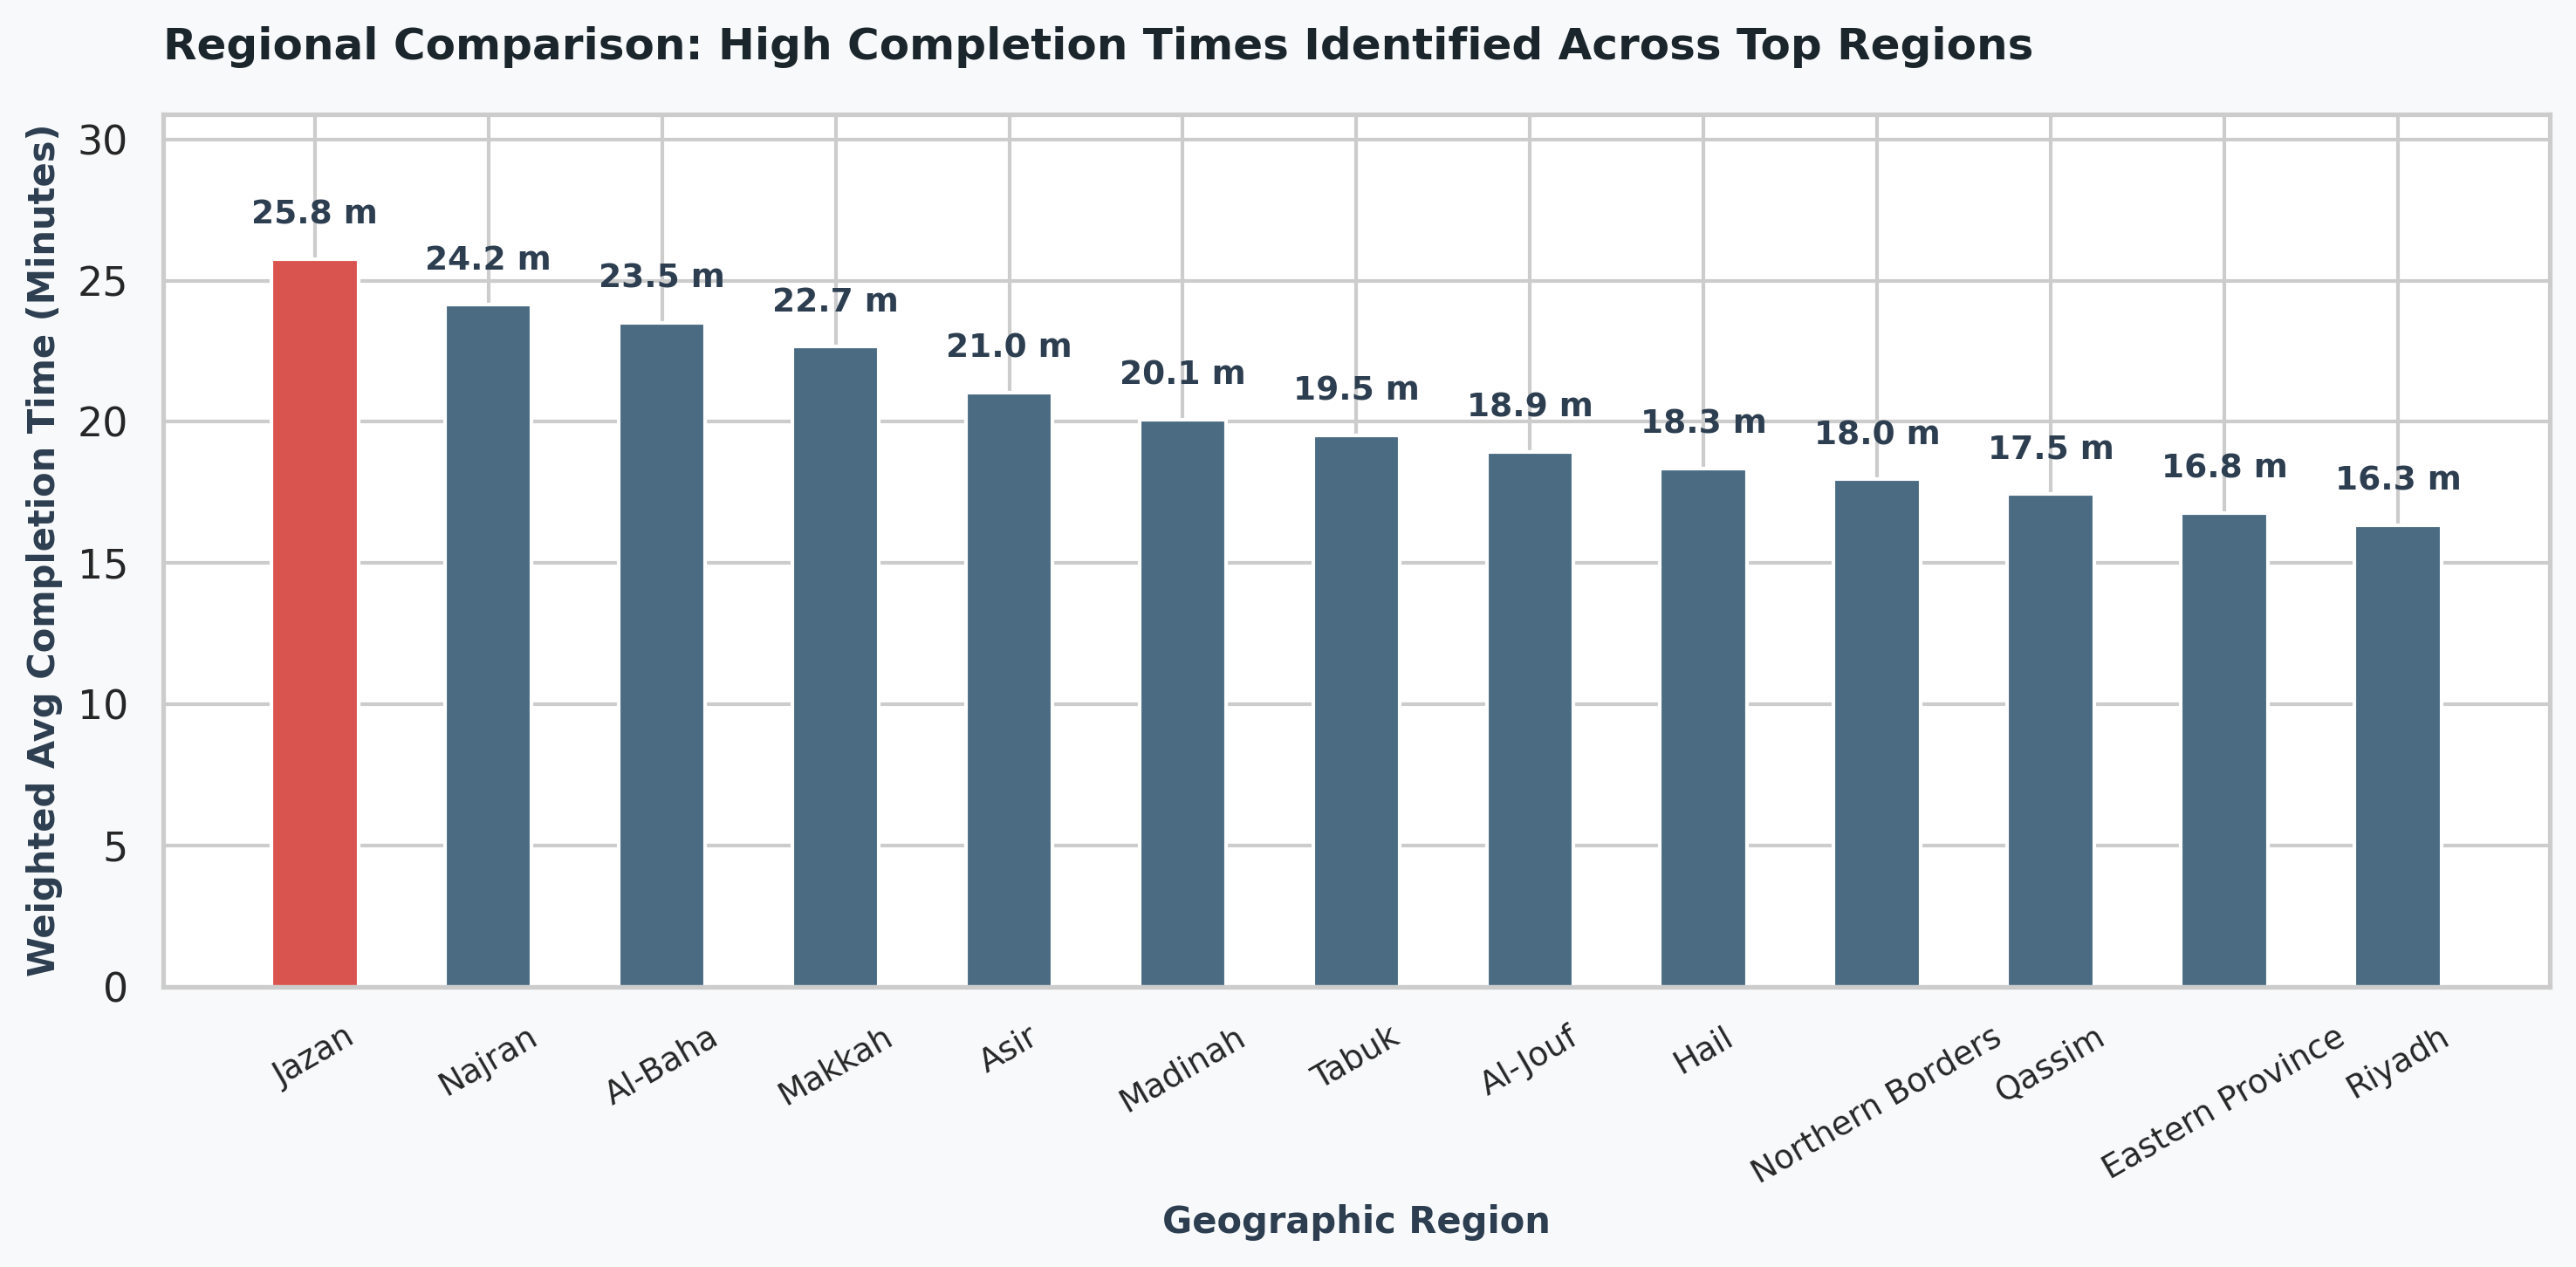


 Success: All PNG files & Interactive HTML files generated successfully!


In [1]:
# ==============================================================================
# Public Service Delivery Analysis Notebook (Google Colab Ready)
# Author: Zainab Abdullah Bohulaigh
# Course: Data Visualization and Storytelling
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# 1. Load Dataset
df = pd.read_csv('tayseer_services.csv')

print("=== Dataset Overview ===")
print(f"Total Rows: {len(df)}")
print(df.head())

# 2. Aggregations (Handling DeprecationWarning safely)
def calc_monthly_metrics(x):
    return pd.Series({
        'weighted_completion_min': (x['avg_completion_min'] * x['transactions']).sum() / x['transactions'].sum(),
        'weighted_sla_met_pct': (x['sla_met_pct'] * x['transactions']).sum() / x['transactions'].sum(),
        'total_transactions': x['transactions'].sum(),
        'total_complaints': x['complaints'].sum()
    })

def calc_region_metrics(x):
    return pd.Series({
        'weighted_completion_min': (x['avg_completion_min'] * x['transactions']).sum() / x['transactions'].sum(),
        'weighted_sla_met_pct': (x['sla_met_pct'] * x['transactions']).sum() / x['transactions'].sum(),
        'total_transactions': x['transactions'].sum(),
        'total_complaints': x['complaints'].sum()
    })

monthly_perf = df.groupby('month', as_index=False).apply(calc_monthly_metrics, include_groups=False)
region_perf = df.groupby('region', as_index=False).apply(calc_region_metrics, include_groups=False).sort_values(by='weighted_completion_min', ascending=False)

# Deduplicated Digital Adoption calculation
digital_clean = df[['month', 'region', 'service_category', 'digital_adoption_pct']].drop_duplicates()
avg_digital_adoption = digital_clean['digital_adoption_pct'].mean()
print(f"\nNational Unique Average Digital Adoption Rate: {avg_digital_adoption:.2f}%")

# ==============================================================================
# 3. Export PNG Static Images using Matplotlib / Seaborn (High Res, Calm Palette)
# ==============================================================================
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# --- Chart 1 Static PNG ---
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

ax.plot(monthly_perf['month'], monthly_perf['weighted_completion_min'],
        color='#2B5B84', marker='o', linewidth=2.5, markersize=7, markerfacecolor='#D9534F')

max_idx = monthly_perf['weighted_completion_min'].idxmax()
max_month = monthly_perf.loc[max_idx, 'month']
max_val = monthly_perf.loc[max_idx, 'weighted_completion_min']

ax.annotate(f'Peak: {max_val:.1f} min', xy=(max_month, max_val), xytext=(max_month, max_val + 5),
            arrowprops=dict(facecolor='#D9534F', shrink=0.05, width=1, headwidth=5),
            fontsize=10, fontweight='bold', color='#D9534F', ha='center')

plt.title('Completion Times Rose Significantly Across Months Peak Period', fontsize=12, fontweight='bold', pad=15, loc='left', color='#1A252C')
plt.xlabel('Month', fontsize=10, fontweight='bold', color='#2C3E50')
plt.ylabel('Weighted Avg Completion Time (Minutes)', fontsize=10, fontweight='bold', color='#2C3E50')
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig('chart1_completion_time_trend.png', dpi=300)
plt.show()

# --- Chart 2 Static PNG ---
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

bar_colors = ['#D9534F' if i == 0 else '#4A6B82' for i in range(len(region_perf))]
bars = ax.bar(region_perf['region'], region_perf['weighted_completion_min'], color=bar_colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.0, f"{yval:.1f} m", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2C3E50')

plt.title('Regional Comparison: High Completion Times Identified Across Top Regions', fontsize=12, fontweight='bold', pad=15, loc='left', color='#1A252C')
plt.xlabel('Geographic Region', fontsize=10, fontweight='bold', color='#2C3E50')
plt.ylabel('Weighted Avg Completion Time (Minutes)', fontsize=10, fontweight='bold', color='#2C3E50')
plt.ylim(0, region_perf['weighted_completion_min'].max() * 1.2)
plt.xticks(rotation=30, fontsize=9)
plt.tight_layout()
plt.savefig('chart2_region_completion_comparison.png', dpi=300)
plt.show()

# ==============================================================================
# 4. Interactive Plotly Visualizations (Generates HTML for Repositories)
# ==============================================================================
# Interactive Chart 1
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=monthly_perf['month'], y=monthly_perf['weighted_completion_min'],
    mode='lines+markers', name='Avg Completion Time',
    line=dict(color='#2B5B84', width=3.5, shape='spline'),
    marker=dict(size=10, color='#D9534F', symbol='circle', line=dict(color='white', width=2)),
    hovertemplate=(
        "<b>Month:</b> %{x}<br>" +
        "<b>Weighted Completion Time:</b> %{y:.1f} mins<br>" +
        "<b>Total Volume:</b> %{customdata[0]:,} transactions<br>" +
        "<b>SLA Compliance:</b> %{customdata[1]:.1f}%<br>" +
        "<b>Complaints Registered:</b> %{customdata[2]:,}<extra></extra>"
    ),
    customdata=np.stack((monthly_perf['total_transactions'], monthly_perf['weighted_sla_met_pct'], monthly_perf['total_complaints']), axis=-1)
))
fig1.update_layout(
    title="<b>Completion Times Rose Significantly Across Months Peak Period</b>",
    xaxis_title="<b>Month</b>", yaxis_title="<b>Weighted Avg Completion Time (Minutes)</b>",
    paper_bgcolor="#F8F9FA", plot_bgcolor="#FFFFFF", font=dict(family="Arial", color="#2C3E50")
)
fig1.write_html("chart1_interactive.html")
fig1.show()

# Interactive Chart 2
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=region_perf['region'], y=region_perf['weighted_completion_min'],
    marker_color=bar_colors, width=0.5,
    text=[f"<b>{val:.1f} m</b>" for val in region_perf['weighted_completion_min']], textposition='outside',
    hovertemplate=(
        "<b>Region:</b> %{x}<br>" +
        "<b>Avg Completion Time:</b> %{y:.1f} mins<br>" +
        "<b>Total Volume:</b> %{customdata[0]:,} transactions<br>" +
        "<b>SLA Compliance Rate:</b> %{customdata[1]:.1f}%<br>" +
        "<b>Total Complaints:</b> %{customdata[2]:,}<extra></extra>"
    ),
    customdata=np.stack((region_perf['total_transactions'], region_perf['weighted_sla_met_pct'], region_perf['total_complaints']), axis=-1)
))
fig2.update_layout(
    title="<b>Regional Comparison: High Completion Times Identified Across Top Regions</b>",
    xaxis_title="<b>Geographic Region</b>", yaxis_title="<b>Weighted Avg Completion Time (Minutes)</b>",
    paper_bgcolor="#F8F9FA", plot_bgcolor="#FFFFFF", font=dict(family="Arial", color="#2C3E50")
)
fig2.write_html("chart2_interactive.html")
fig2.show()

print("\n Success: All PNG files & Interactive HTML files generated successfully!")